## 1. Environment Setup

#### 1a) Testing Jupyter
+ Testing Jupyter to ensure kernel, libraries, and distributed system (Spark/Cassandra/Docker) are all properly connected and working before running real workloads

In [3]:
print("Jupyter is working")

Jupyter is working


#### 1b) Start Spark Engine
+ To initialize the distributed processing system, so that we can run large-scale data computations across multiple nodes efficiently

In [8]:
spark = SparkSession.builder \
    .appName("Test") \
    .master("local[*]") \
    .config("spark.cassandra.connection.host", "cassandra") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FixTest") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

print(spark)

In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()
print(spark)

In [10]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Test") \
    .master("local[*]") \
    .getOrCreate()

In [11]:
spark = SparkSession.builder \
    .appName("test") \
    .config("spark.cassandra.connection.host", "cassandra") \
    .getOrCreate()

## 2. Check Environment

#### 2a) Current working directory

In [4]:
import os
os.getcwd()

'/home/jovyan'

#### 2b) Confirmed versions

#### Java version (Spark needs Java)
+ Ensure system has a compatible JVM installed
+ So, Spark can run without errors and avoid version mismatch issues that can break initialization or cluster communication

In [2]:
!java -version

openjdk version "17.0.8.1" 2023-08-24
OpenJDK Runtime Environment (build 17.0.8.1+1-Ubuntu-0ubuntu122.04)
OpenJDK 64-Bit Server VM (build 17.0.8.1+1-Ubuntu-0ubuntu122.04, mixed mode, sharing)


#### Python version
+ Ensure code and libraries are compatible wih the installed Python runtime, preventing errors from version mismatch or unsupported features

In [5]:
import sys
print(sys.version)

3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]


#### PySpark version
+ Ensure it matches installed Spark and Hadoop environment, so all components are compatible and can runs without API or dependency errors

In [6]:
import pyspark
print(pyspark.__version__)

3.5.0


#### Cassandra version
+ Ensure it compatible with Spark Cassandra connector and drivers, so data can be read/ written correctly without connection, schema or protocol errors

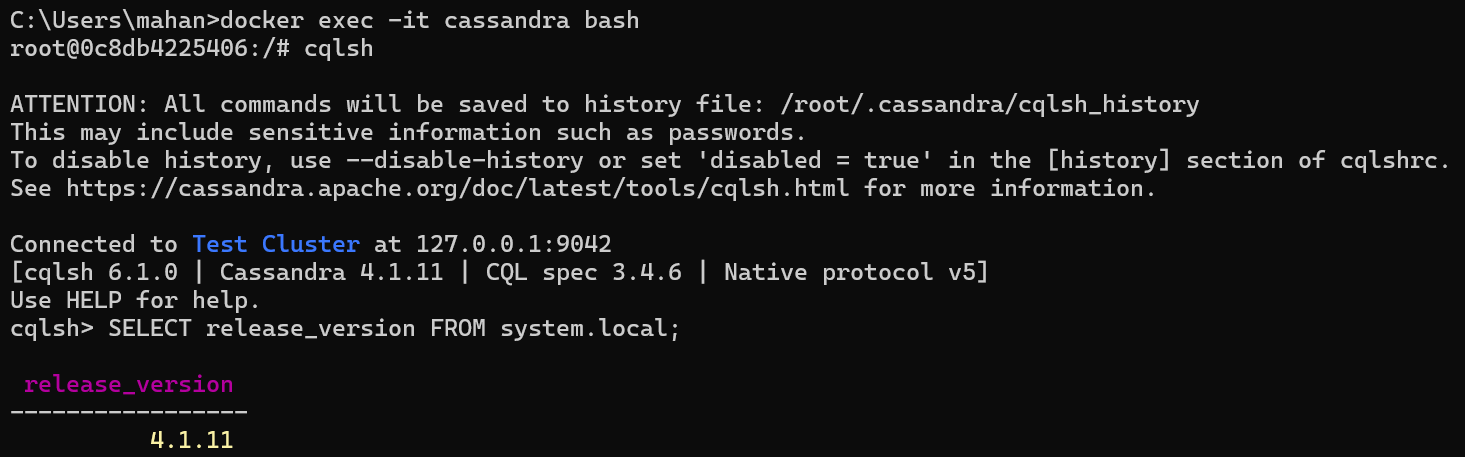

In [7]:
from PIL import Image
from IPython.display import display

img = Image.open("cassandra version.png")
display(img)

## 3. Connect spark with Cassandra
+ Loads the Cassandra connector package and sets the host. This is the complete setup required for Spark <-> Cassandra operations.

In [12]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens-Cassandra") \
    .config("spark.jars.packages", 
            "com.datastax.spark:spark-cassandra-connector_2.12:3.4.1") \
    .config("spark.cassandra.connection.host", "127.0.0.1") \
    .getOrCreate()

## 4. Load and parse dataset into HDFS
In the MovieLens 100K dataset, 3 files were uploaded:
+ u.data
  + Contains the ratings (user ID, movie ID, rating, timestamp)
  + This is the main file for analysis like average rating
+ u.item
  + Contains movie information (movie ID, title, genre, etc.)
  + Used to map movieIDs to actual movie names
+ u.user
  + Contains user information (user ID, age, gender, occupation, zip code)
  + Used for user-based analysis

The MovieLens dataset was first uploaded into HDFS to enable distributed processing.

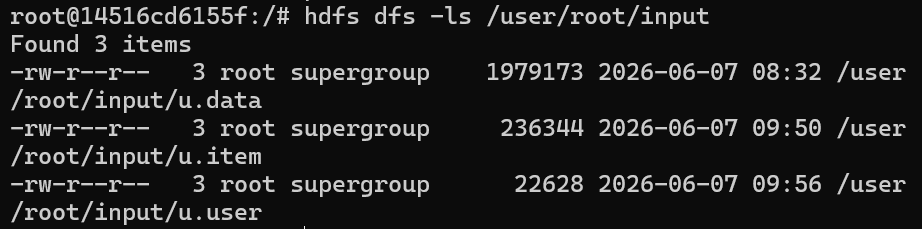

In [19]:
from PIL import Image
from IPython.display import display

img = Image.open("load.png")
display(img)

#### 4a) u.data dataset

#### Create RDD from file stored in HDFS
+ Apache Spark was then used to load the dataset from HDFS as Resilient Distributed Datasets (RDDs). Each record in the dataset represents a single user-movie interaction.

In [13]:
data_rdd = spark.sparkContext.textFile("hdfs://namenode:8020/user/root/input/u.data")
data_rdd.take(5)

['196\t242\t3\t881250949',
 '186\t302\t3\t891717742',
 '22\t377\t1\t878887116',
 '244\t51\t2\t880606923',
 '166\t346\t1\t886397596']

#### Split RDD 
+ Raw RDD was transformed by splitting each row into separate columns

In [14]:
from pyspark.sql.functions import split, col
data_split = data_rdd.map(lambda x: x.split("\t"))

#### Convert RDD to DataFrame
+ The processed RDD was converted into a Spark DataFrame to support SQL-based querying and integration with Cassandra.

In [15]:
data_df = data_split.toDF(["user_id", "movie_id", "rating", "timestamp"])
data_df.show(5)
data_df.printSchema()

+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|    196|     242|     3|881250949|
|    186|     302|     3|891717742|
|     22|     377|     1|878887116|
|    244|      51|     2|880606923|
|    166|     346|     1|886397596|
+-------+--------+------+---------+
only showing top 5 rows

root
 |-- user_id: string (nullable = true)
 |-- movie_id: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- timestamp: string (nullable = true)



#### 4b) u.item dataset

#### Create RDD from file stored in HDFS
+ Apache Spark was then used to load the dataset from HDFS as Resilient Distributed Datasets (RDDs). Each record in the dataset represents a single user-movie interaction.

In [16]:
item_rdd = spark.sparkContext.textFile("hdfs://namenode:8020/user/root/input/u.item")
item_rdd.take(5)

['1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0',
 '2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0',
 '3|Four Rooms (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0',
 '4|Get Shorty (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995)|0|1|0|0|0|1|0|0|1|0|0|0|0|0|0|0|0|0|0',
 '5|Copycat (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Copycat%20(1995)|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|1|0|0']

#### Split RDD 
+ Raw RDD was transformed by splitting each row into separate columns

In [17]:
item_split = item_rdd.map(lambda x: x.split("|"))

#### Convert RDD to DataFrame
+ The processed RDD was converted into a Spark DataFrame to support SQL-based querying and integration with Cassandra.

In [18]:
columns = [
    "movie_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url"
] + [f"genre_{i}" for i in range(19)]

item_df = item_split.toDF(columns)

item_df.show(5)
item_df.printSchema()

+--------+-----------------+------------+------------------+--------------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
|movie_id|            title|release_date|video_release_date|            imdb_url|genre_0|genre_1|genre_2|genre_3|genre_4|genre_5|genre_6|genre_7|genre_8|genre_9|genre_10|genre_11|genre_12|genre_13|genre_14|genre_15|genre_16|genre_17|genre_18|
+--------+-----------------+------------+------------------+--------------------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
|       1| Toy Story (1995)| 01-Jan-1995|                  |http://us.imdb.co...|      0|      0|      0|      1|      1|      1|      0|      0|      0|      0|       0|       0|       0|       0|       0|       0|       0|       0|       0|
|       2| GoldenEye (1995)|

#### 4c) u.user dataset

#### Create RDD from file stored in HDFS
+ Apache Spark was then used to load the dataset from HDFS as Resilient Distributed Datasets (RDDs). Each record in the dataset represents a single user-movie interaction.

In [19]:
user_rdd = spark.sparkContext.textFile("hdfs://namenode:8020/user/root/input/u.user")
user_rdd.take(5)

['1|24|M|technician|85711',
 '2|53|F|other|94043',
 '3|23|M|writer|32067',
 '4|24|M|technician|43537',
 '5|33|F|other|15213']

#### Split RDD 
+ Raw RDD was transformed by splitting each row into separate columns

In [20]:
user_split = user_rdd.map(lambda x: x.split("|"))

#### Convert RDD to DataFrame
+ The processed RDD was converted into a Spark DataFrame to support SQL-based querying and integration with Cassandra.

In [21]:
user_df = user_split.toDF(["user_id", "age", "gender", "occupation", "zip"])

user_df.show(5)
user_df.printSchema()

+-------+---+------+----------+-----+
|user_id|age|gender|occupation|  zip|
+-------+---+------+----------+-----+
|      1| 24|     M|technician|85711|
|      2| 53|     F|     other|94043|
|      3| 23|     M|    writer|32067|
|      4| 24|     M|technician|43537|
|      5| 33|     F|     other|15213|
+-------+---+------+----------+-----+
only showing top 5 rows

root
 |-- user_id: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip: string (nullable = true)



## 5. Data cleaning & preprocessing 
+ Data cleaning steps included splitting fields, null removal and duplicate handling to ensure data quality before analysis

#### Casting columns into integer (u.data dataset)

In [22]:
data_df = data_df.select(
    col("user_id").cast("int"),
    col("movie_id").cast("int"),
    col("rating").cast("int"),
    col("timestamp").cast("int")
)

#### Check schema (structure for u.data dataset)

In [23]:
data_df.printSchema()
data_df.select("rating").show(5)

root
 |-- user_id: integer (nullable = true)
 |-- movie_id: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+
|rating|
+------+
|     3|
|     3|
|     1|
|     2|
|     1|
+------+
only showing top 5 rows



#### Remove null values and duplicate rows

In [24]:
data_clean = data_df.dropna().dropDuplicates()
item_clean = item_df.dropna().dropDuplicates()
user_clean = user_df.dropna().dropDuplicates()

## 6. Analytical task

#### Register cleaned DataFrame as SQL temporary view
+ The createOrReplaceTempView() function is used to register cleaned Spark DataFrames as temporary SQL views. This allows the DataFrames to be queried using Spark SQL, treating them as relational database tables.
+ In this project, the cleaned datasets for u.data, u.item, and u.user are registered as “ratings”, “movies”, and “users” respectively, enabling SQL-based analytical operations.

In [69]:
data_clean.createOrReplaceTempView("ratings")
item_clean.createOrReplaceTempView("movies")
user_clean.createOrReplaceTempView("users")

#### Task i) Average rating for each movie
Interpretation:
+ The query calculates the average rating for each movie using aggregation on the ratings dataset.

In [70]:
avg_rating = spark.sql("""
SELECT 
    movie_id,
    COUNT(rating) AS total_ratings,
    ROUND(AVG(rating), 2) AS avg_rating
FROM ratings
GROUP BY movie_id
""")

avg_rating.show()

+--------+-------------+----------+
|movie_id|total_ratings|avg_rating|
+--------+-------------+----------+
|     496|          231|      4.12|
|     148|          128|       3.2|
|     471|          221|      3.61|
|     463|           71|      3.86|
|     833|           49|       3.2|
|    1088|           13|      2.23|
|    1591|            6|      3.17|
|    1580|            1|       1.0|
|    1238|            8|      3.13|
|    1342|            2|       2.5|
|    1645|            1|       4.0|
|     737|           59|      2.98|
|    1084|           21|      3.86|
|     623|           39|      2.92|
|     392|           68|      3.54|
|     243|          132|      2.44|
|     540|           43|      2.51|
|    1025|           44|      2.93|
|    1507|            1|       3.0|
|    1483|           12|      3.42|
+--------+-------------+----------+
only showing top 20 rows



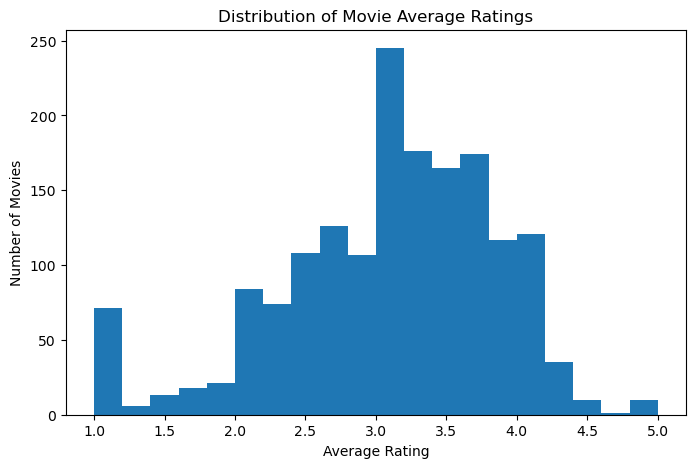

In [71]:
# Convert Spark DataFrame into Pandas
pdf = avg_rating.select("avg_rating").toPandas()

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pdf["avg_rating"], bins=20)
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Average Ratings")
plt.show()

Discussion:
+ This histogram shows how movie average ratings are distributed across the dataset. Most movies cluster around an average rating of 3.0, indicating that viewers tend to give moderate ratings rather than extreme ones.
+ The distribution is roughly bell-shaped, suggesting a normal-like pattern where very low (around 1.0) and very high (around 5.0) ratings are relatively rare.

### Task ii) Top 10 movies with the highest average ratings 
Interpretation:
+ This task identifies the top 10 movies with the highest average ratings, highlighting the most well-received movies in the dataset.

In [72]:
top10_movies = spark.sql("""
SELECT 
    m.movie_id,
    m.title,
    ROUND(AVG(r.rating), 2) AS avg_rating,
    COUNT(r.rating) AS total_ratings
FROM ratings r
JOIN movies m
ON r.movie_id = m.movie_id
GROUP BY m.movie_id, m.title
HAVING COUNT(r.rating) >= 20
ORDER BY avg_rating DESC
LIMIT 10
""")

top10_movies.show()

+--------+--------------------+----------+-------------+
|movie_id|               title|avg_rating|total_ratings|
+--------+--------------------+----------+-------------+
|     408|Close Shave, A (1...|      4.49|          112|
|     169|Wrong Trousers, T...|      4.47|          118|
|     318|Schindler's List ...|      4.47|          298|
|     483|   Casablanca (1942)|      4.46|          243|
|      64|Shawshank Redempt...|      4.45|          283|
|     114|Wallace & Gromit:...|      4.45|           67|
|      12|Usual Suspects, T...|      4.39|          267|
|     603|  Rear Window (1954)|      4.39|          209|
|      50|    Star Wars (1977)|      4.36|          583|
|     178| 12 Angry Men (1957)|      4.34|          125|
+--------+--------------------+----------+-------------+



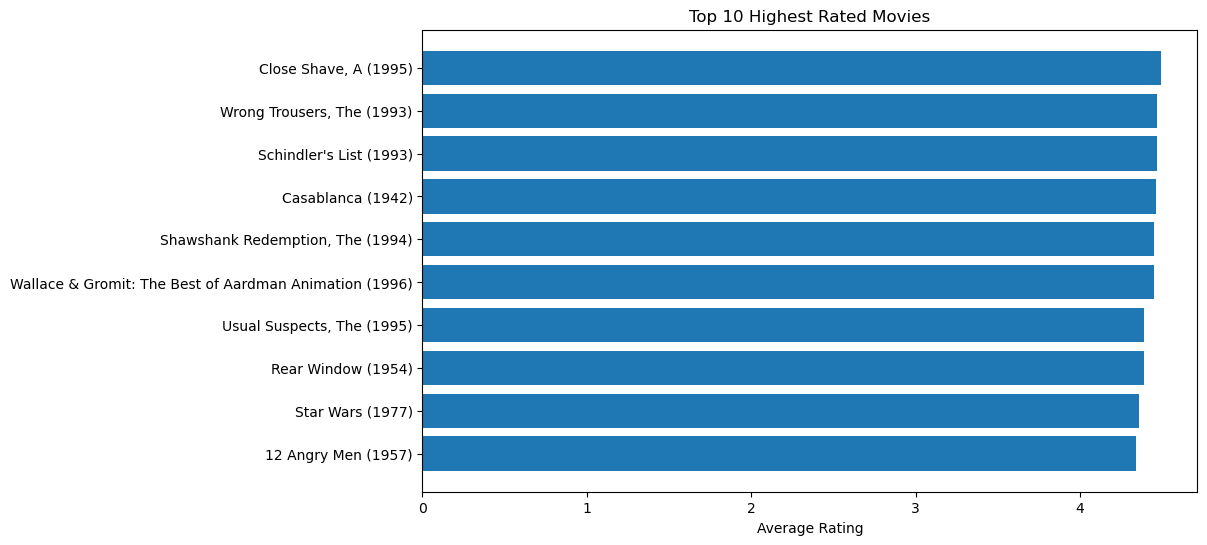

In [73]:
# Convert Spark DataFrame into Pandas
top10 = top10_movies.toPandas()

# Plotting
plt.figure(figsize=(10,6))
plt.barh(top10["title"], top10["avg_rating"])
plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Average Rating")
plt.gca().invert_yaxis()
plt.show()

Discussion:
+ This bar chart highlights the top 10 highest-rated movies based on average ratings. Each bar represents a film, showing that all of them have ratings close to or above 4.0, indicating exceptional viewer appreciation.
+ The list includes a mix of classic films like Casablanca (1942) and 12 Angry Men (1957), alongside modern masterpieces such as Schindler’s List (1993) and The Shawshank Redemption (1994).
+ Interestingly, two Wallace & Gromit titles (A Close Shave and The Wrong Trousers) appear, showing that high-quality animation can achieve ratings comparable to live-action dramas.
+ The consistent ratings across decades suggest that timeless storytelling and strong emotional impact are key factors in earning top audience scores.

### Task iii) Users who have rated at least 50 movies & their favourite movie genre 
Interpretation:
+ This analysis identifies users who have rated at least 50 movies and determines their most frequently rated genre, representing their preferred movie category

#### Step 1: Active users (≥50 ratings)

In [92]:
active_users = spark.sql("""
SELECT 
    user_id,
    COUNT(*) AS total_ratings
FROM ratings
GROUP BY user_id
HAVING COUNT(*) >= 50
""")

active_users.createOrReplaceTempView("active_users")

#### Step 2: Join ratings + movies

In [85]:
user_movies = spark.sql("""
SELECT 
    r.user_id,
    r.movie_id,
    m.genre_0,
    m.genre_1,
    m.genre_2,
    m.genre_3,
    m.genre_4,
    m.genre_5,
    m.genre_6
FROM ratings r
JOIN movies m
ON r.movie_id = m.movie_id
""")

user_movies.createOrReplaceTempView("user_movies")

#### Step 3: Genre decoding

In [86]:
user_genres = spark.sql("""
SELECT 
    user_id,
    movie_id,
    genre
FROM (
    SELECT 
        user_id,
        movie_id,
        CASE 
            WHEN genre_0 = 1 THEN 'Action'
            WHEN genre_1 = 1 THEN 'Comedy'
            WHEN genre_2 = 1 THEN 'Drama'
            WHEN genre_3 = 1 THEN 'Romance'
            WHEN genre_4 = 1 THEN 'Thriller'
            WHEN genre_5 = 1 THEN 'SciFi'
            WHEN genre_6 = 1 THEN 'Horror'
        END AS genre
    FROM user_movies
)
WHERE genre IS NOT NULL
""")

user_genres.createOrReplaceTempView("user_genres")

#### Step 4: Keep only active users

In [87]:
filtered_genres = spark.sql("""
SELECT g.*
FROM user_genres g
JOIN active_users a
ON g.user_id = a.user_id
""")

filtered_genres.createOrReplaceTempView("filtered_genres")

#### Step 5: Count genre frequency per user

In [88]:
user_genre_count = spark.sql("""
SELECT 
    user_id,
    genre,
    COUNT(*) AS genre_count
FROM filtered_genres
GROUP BY user_id, genre
""")

user_genre_count.createOrReplaceTempView("user_genre_count")

#### Step 6: Get favourite genre per user

In [89]:
final_result = spark.sql("""
SELECT user_id, genre, genre_count
FROM (
    SELECT 
        user_id,
        genre,
        genre_count,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY genre_count DESC) AS rn
    FROM user_genre_count
)
WHERE rn = 1
""")

final_result.show()

+-------+------+-----------+
|user_id| genre|genre_count|
+-------+------+-----------+
|      1|Comedy|         75|
|      2| SciFi|         14|
|      3|Comedy|         14|
|      5|Comedy|         56|
|      6| SciFi|         48|
|      7|Comedy|         95|
|      8|Comedy|         39|
|     10| SciFi|         40|
|     11| SciFi|         65|
|     12|Comedy|         14|
|     13|Comedy|        156|
|     14| SciFi|         27|
|     15|Comedy|         22|
|     16| SciFi|         31|
|     18| SciFi|         89|
|     21|Comedy|         39|
|     22|Comedy|         66|
|     23|Comedy|         39|
|     24| SciFi|         15|
|     25|Comedy|         20|
+-------+------+-----------+
only showing top 20 rows



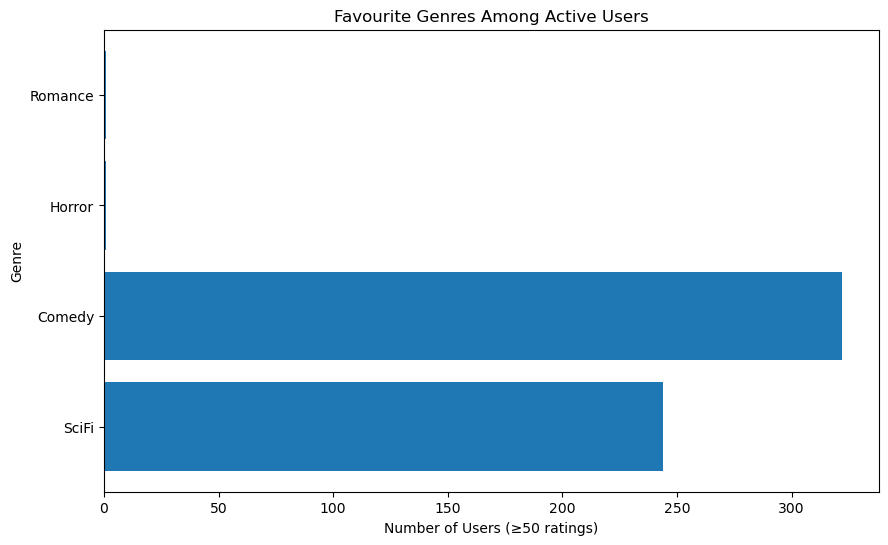

In [94]:
# Convert Spark DataFrame to Pandas
pdf = final_result.groupBy("genre").count().toPandas()

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(pdf["genre"], pdf["count"])
plt.xlabel("Number of Users (≥50 ratings)")
plt.ylabel("Genre")
plt.title("Favourite Genres Among Active Users")
plt.gca().invert_yaxis()
plt.show()

Discussion:
+ The bar chart shows the distribution of favourite movie genres among users who have rated at least 50 movies. This filtering ensures that only active and reliable users are included in the analysis, reducing bias from users with very few ratings.
+ From the results, Comedy is the most preferred genre, with the highest number of active users selecting it as their dominant genre. This suggests that light-hearted and entertaining content is the most frequently enjoyed among consistent users.
+ The second most popular genre is Sci-Fi, indicating a strong interest in imaginative and technology-based storytelling among users. This may reflect the popularity of science fiction movies that involve futuristic or action-driven themes.
+ On the other hand, genres such as Horror and Romance have significantly lower counts. This indicates that fewer active users consistently rate movies from these categories as their most frequent genre, suggesting they are less dominant in overall viewing preferences.
+ Overall, the analysis reveals that user preferences are concentrated in a few major genres, with Comedy and Sci-Fi dominating the viewing behavior of active users. This insight can be useful for recommendation systems, as it highlights which genres are most likely to engage highly active users.

### Task iv) All users who are less than 20 years old 
Interpretation: 
+ This task filters users who are below 20 years old, providing insight into the younger demographic in the dataset.

In [95]:
young_users = spark.sql("""
SELECT *
FROM users
WHERE age < 20
""")

young_users.show()

+-------+---+------+-------------+-----+
|user_id|age|gender|   occupation|  zip|
+-------+---+------+-------------+-----+
|    289| 11|     M|         none|94619|
|    462| 19|     F|      student|02918|
|    375| 17|     M|entertainment|37777|
|    368| 18|     M|      student|92113|
|    341| 17|     F|      student|44405|
|    223| 19|     F|      student|47906|
|    393| 19|     M|      student|83686|
|    367| 17|     M|      student|37411|
|    434| 16|     F|      student|49705|
|    206| 14|     F|      student|53115|
|    281| 15|     F|      student|06059|
|    451| 16|     M|      student|48446|
|    471| 10|     M|      student|77459|
|    262| 19|     F|      student|78264|
|    221| 19|     M|      student|20685|
|     36| 19|     F|      student|93117|
|    110| 19|     M|      student|77840|
|    270| 18|     F|      student|63119|
|     30|  7|     M|      student|55436|
|    303| 19|     M|      student|14853|
+-------+---+------+-------------+-----+
only showing top

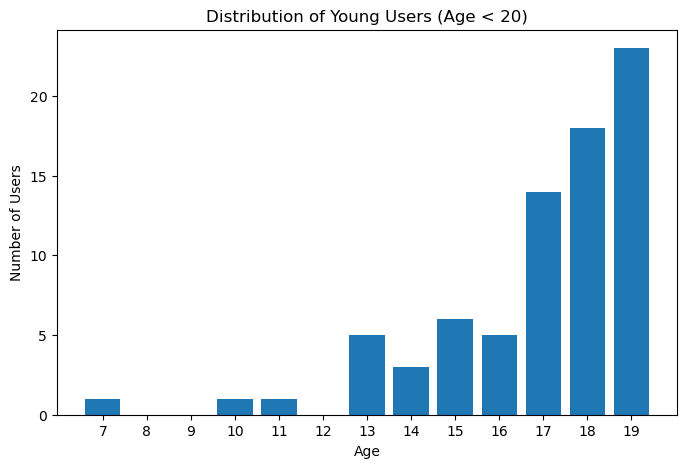

In [100]:
import pandas as pd

# Convert to pandas
age_df = young_users.groupBy("age").count().orderBy("age").toPandas()

# Ensure both columns are numeric before merging
age_df["age"] = age_df["age"].astype(int)

# Create full age range and merge
all_ages = pd.DataFrame({"age": range(7, 20)})
age_df = pd.merge(all_ages, age_df, on="age", how="left").fillna(0)

plt.figure(figsize=(8,5))
plt.bar(age_df["age"], age_df["count"])
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Distribution of Young Users (Age < 20)")
plt.xticks(age_df["age"])
plt.show()


Discussion:
+ The distribution of young users under 20 years old reveals that the majority of participants are concentrated in the late teenage years, particularly between ages 15 and 19. This suggests that the dataset is dominated by older adolescents, who are more likely to engage with movie rating platforms compared to younger children. + The inclusion of ages with zero counts (such as 8, 9, and 12) ensures a complete representation of the age range, highlighting the absence of users in those categories. Interestingly, the presence of very low ages, such as 7, may reflect either rare participation by very young users or potential data entry inconsistencies.
+ Overall, the plot emphasizes that the active young user base is skewed toward older teenagers, which has important implications for analyzing movie preferences and viewing behavior across age groups.

### v) Scientist age between 30-40 years old
Interpretation: 
+ This analysis focuses on users whose occupation is “scientist” and whose age falls between 30 and 40 years old.

In [101]:
scientists = spark.sql("""
SELECT *
FROM users
WHERE occupation = 'scientist'
AND age BETWEEN 30 AND 40
""")

scientists.show()

+-------+---+------+----------+-----+
|user_id|age|gender|occupation|  zip|
+-------+---+------+----------+-----+
|    430| 38|     M| scientist|98199|
|    107| 39|     M| scientist|60466|
|     71| 39|     M| scientist|98034|
|    272| 33|     M| scientist|53706|
|    337| 37|     M| scientist|10522|
|    183| 33|     M| scientist|27708|
|     40| 38|     M| scientist|27514|
|     74| 39|     M| scientist|T8H1N|
|    309| 40|     M| scientist|70802|
|    554| 32|     M| scientist|62901|
|    543| 33|     M| scientist|95123|
|    643| 39|     M| scientist|55122|
|    918| 40|     M| scientist|70116|
|    538| 31|     M| scientist|21010|
|    730| 31|     F| scientist|32114|
|    874| 36|     M| scientist|37076|
+-------+---+------+----------+-----+



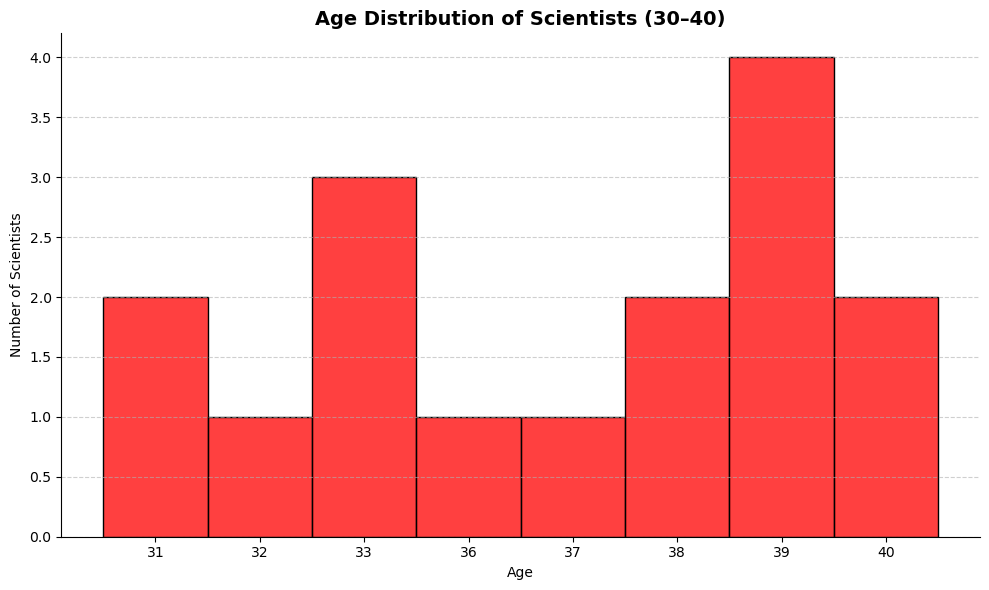

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

# Filter scientists aged 30–40
scientists = user_clean.filter(
    (col("occupation") == "scientist") &
    (col("age").between(30, 40))
)

# Convert Spark DataFrame to Pandas
scientists_pd = scientists.toPandas()

# Sort by age (ascending)
scientists_pd_sorted = scientists_pd.sort_values(by="age")

# Plot histogram with sorted ages
plt.figure(figsize=(10,6))
sns.histplot(scientists_pd_sorted['age'], bins=10, color='red', edgecolor='black')

plt.title("Age Distribution of Scientists (30–40)", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Number of Scientists")
plt.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()


Discussion:
+ The results highlight a specific professional group with potential for more analytical or structured viewing preferences. Scientists in this age range may demonstrate different rating behaviours compared to other occupations, possibly showing more consistent or critical evaluation patterns. This segmentation helps in understanding how occupation and age influence movie preferences.

#### Overall Discussion for analytical task
The analysis of the MovieLens dataset reveals meaningful patterns in user behaviour based on ratings, age, and occupation. The combination of aggregation and filtering techniques in Spark enables efficient extraction of insights related to movie popularity and user preferences. These findings can support recommendation system development and user segmentation analysis.

## 7. Write DataFrame into Cassandra 
This step means saving the results of Spark analysis (DataFrames) into Apache Cassandra, which is a distributed NoSQL database.

#### 7a) Create keyspace
Keyspace in Cassandra is similar to a database

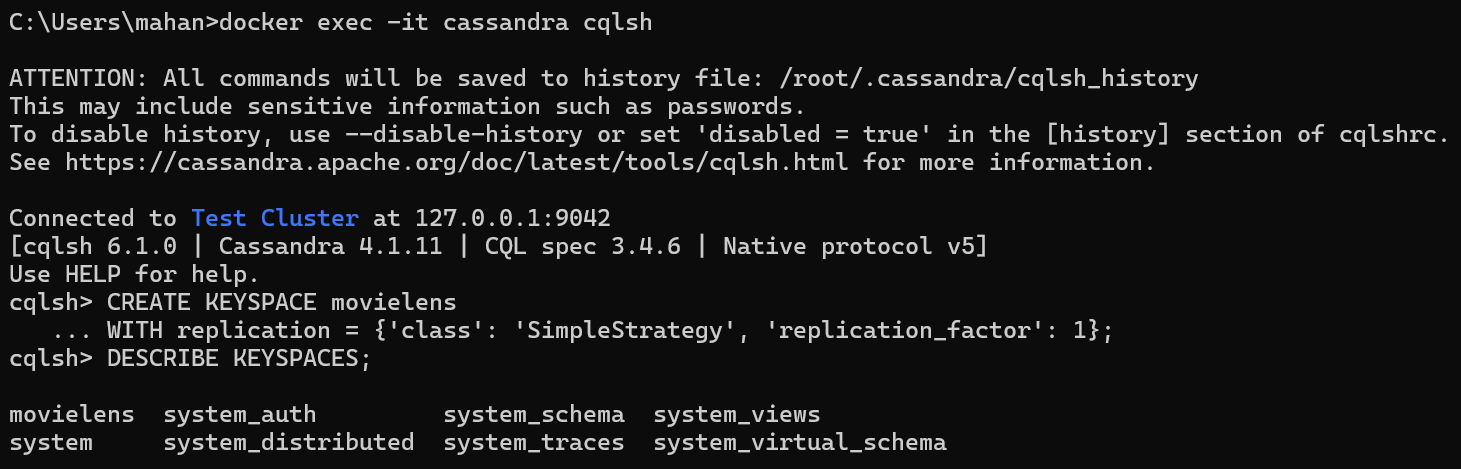

In [57]:
img = Image.open("keyspace.png")
display(img)

#### 7b) Create table
A table is where the processed data is stored

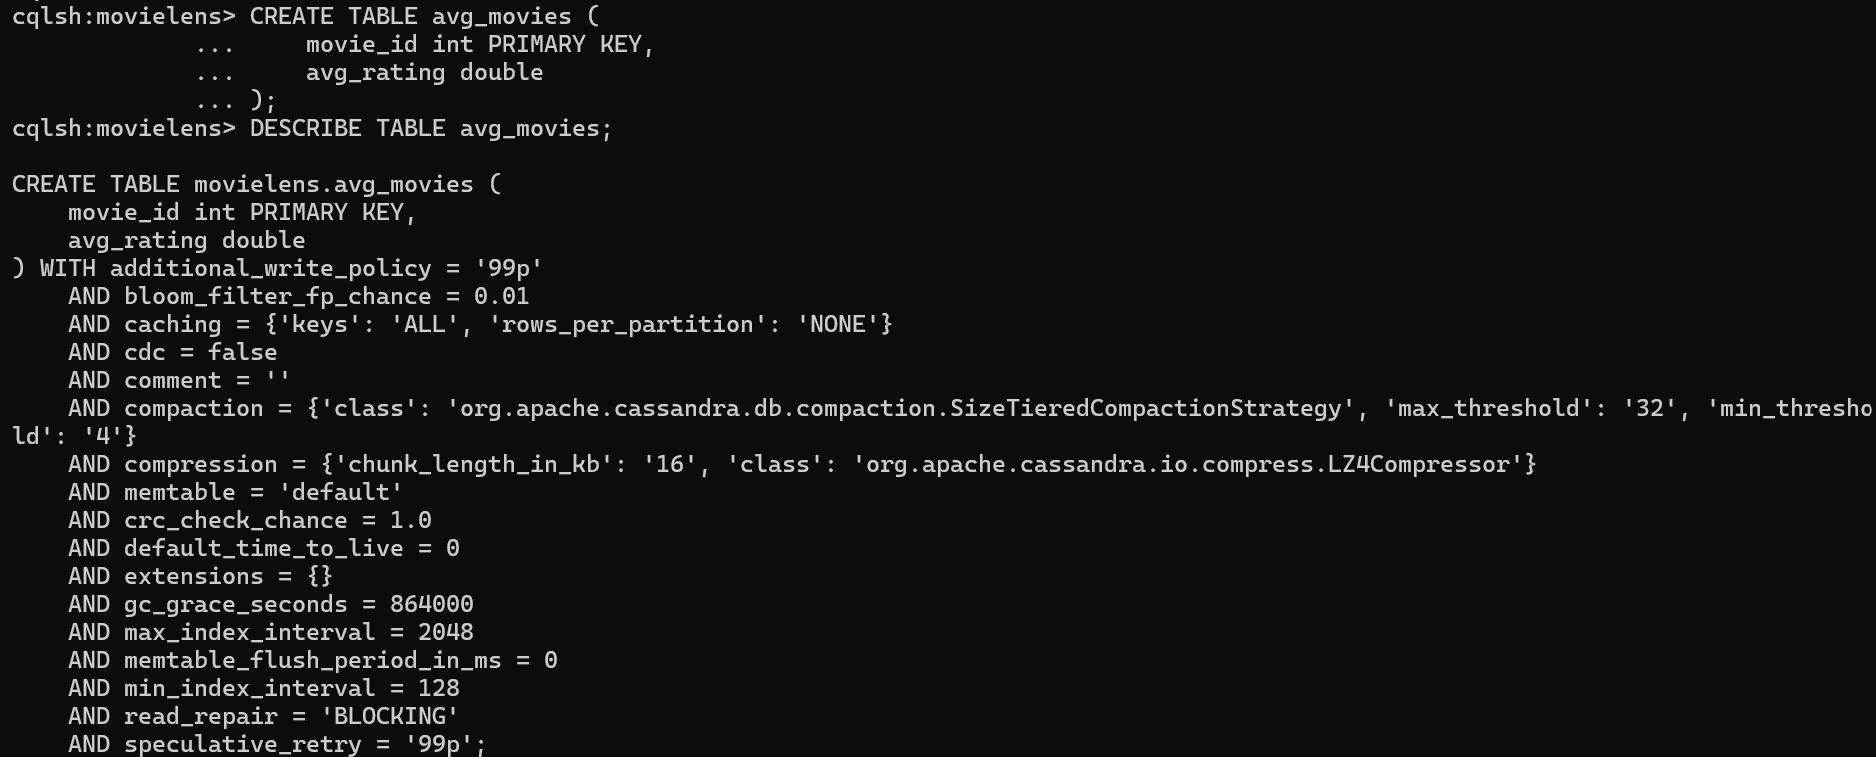

In [58]:
img = Image.open("table1.png")
display(img)

#### avg_movies table is created (Cassandra table)

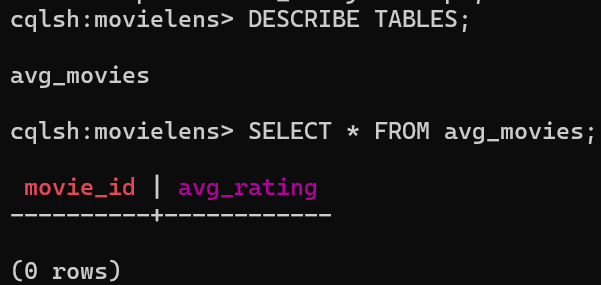

In [59]:
img = Image.open("table2.png")
display(img)

After performing data processing and analysis in Spark, the final results (such as average movie ratings) are stored in Cassandra tables. 

This allows the data to be:
+ Persisted for long-term storage
+ Easily accessed by other applications
+ Shared across distributed systems

This step ensures that the processed output is not temporary in Spark memory but is saved in a structured database format for future use.

In [60]:
#latest (after troubleshoot)
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CassandraSpark") \
    .config("spark.cassandra.connection.host", "cassandra") \
    .getOrCreate()

#### 7c) Write DataFrame to Cassandra
+ Spark results are now stored in Cassandra

In [42]:
avg_rating.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \

    .options(table="avg_movies", keyspace="movielens") \
    .save()

## 8. Read data from Cassandra
Load the Cassandra table back into Spark as DataFrame

In [61]:
cassandra_df = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="avg_movies", keyspace="movielens") \
    .load()

cassandra_df.show()

+--------+------------------+
|movie_id|        avg_rating|
+--------+------------------+
|     375|1.9565217391304348|
|     355| 2.926829268292683|
|     851|              3.75|
|      99|3.7093023255813953|
|     222|  3.66027397260274|
|     755|            3.3125|
|     160| 3.463768115942029|
|    1308|               1.0|
|     390|               3.2|
|    1130|               4.0|
|      11| 3.847457627118644|
|    1342|               2.5|
|     280|3.1882352941176473|
|    1456|3.7142857142857144|
|     859|2.6666666666666665|
|     151|3.6319018404907975|
|    1054|2.3043478260869565|
|     854|             3.375|
|     252|2.9430379746835444|
|       1|3.8783185840707963|
+--------+------------------+
only showing top 20 rows



In [62]:
cassandra_df.orderBy("avg_rating", ascending=False).show(10)

+--------+----------+
|movie_id|avg_rating|
+--------+----------+
|    1467|       5.0|
|    1536|       5.0|
|     814|       5.0|
|    1189|       5.0|
|    1201|       5.0|
|    1500|       5.0|
|    1653|       5.0|
|    1599|       5.0|
|    1293|       5.0|
|    1122|       5.0|
+--------+----------+
only showing top 10 rows



By reading the Cassandra tables back into Spark, we can verify:
+ The data was successfully written
+ The structure (schema) is correct
+ No data loss or corruption occurred during storage

This process is called data validation, and it ensures consistency between Spark processing results and Cassandra storage. It also allows further analysis or visualization using Spark after retrieving the stored data.

## 9. Conclusion:
Overall, this project helped me understand how movie rating data can be analysed using big data tools like Spark and Cassandra. By going through different steps such as calculating average ratings, finding popular movies, and looking at user preferences, I was able to see clear patterns in how people rate and choose movies.

The results show that most users tend to give quite high ratings, especially for popular movies, and users who are more active usually have clear genre preferences. It was also interesting to see how age and occupation can influence movie choices.

Finally, storing the results in Cassandra and checking them back in Spark made the whole process more reliable and complete. This project really shows how big data tools can turn raw data into useful and meaningful insights.